# Task 1 Workbook — Duality and Electricity Markets
### Project 4 · ECON-238

Six plots across two parts:
- **Part 1c** — deterministic dispatch, dual variables, strong duality (Plots 1–3)
- **Part 1e** — n−1 security with reserve, monolithic vs. robust counterpart (Plots 4–6)

Results are read from the CSVs written by `task1c.jl` and `task1e.jl`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})

BASE = '.'
r1c  = os.path.join(BASE, 'results', 'task1c')
r1e  = os.path.join(BASE, 'results', 'task1e')

dispatch = pd.read_csv(os.path.join(r1c, 'dispatch.csv'))
duals    = pd.read_csv(os.path.join(r1c, 'duals.csv'))
dr       = pd.read_csv(os.path.join(r1e, 'dispatch_reserve.csv'))
security = pd.read_csv(os.path.join(r1e, 'security_check.csv'))
obj_df   = pd.read_csv(os.path.join(r1e, 'objectives.csv'))

c  = dispatch['c'].values
Q  = dispatch['Q'].values
g  = dispatch['g_opt'].values
d  = 120.0

dm      = duals[duals['source'] == 'dual_model'].iloc[0]
pi_star = float(dm['pi'])
beta    = np.array([float(dm['beta_1']), float(dm['beta_2']), float(dm['beta_3'])])

print('g*     =', g)
print('C*     =', (c * g).sum())
print('pi*    =', pi_star)
print('beta*  =', beta)

g*     = [100.  20.   0.]
C*     = 13000.0
pi*    = 150.0
beta*  = [50.  0.  0.]


---
## Part 1c — Deterministic Dispatch: Primal, Dual, Strong Duality

**System:** c = (100, 150, 500) \$/MWh · Q = (100, 50, 120) MWh · d = 120 MWh  
**Solution:** g\* = (100, 20, 0) · C\* = \$13,000/h · π\* = \$150/MWh · β\* = (50, 0, 0)

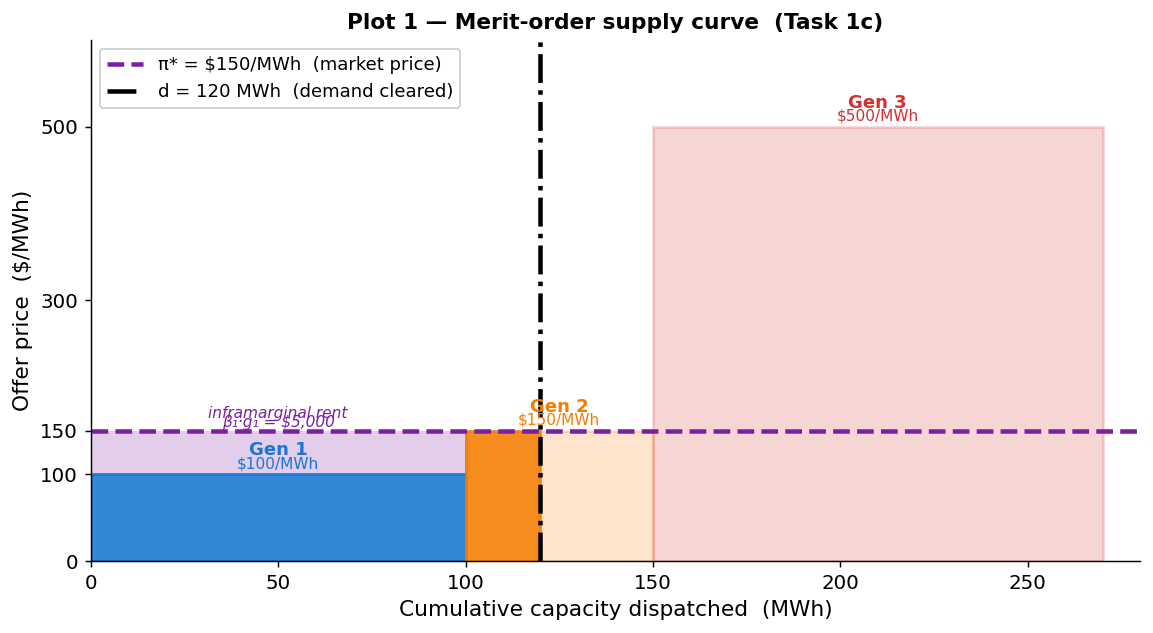

In [8]:
# ── Plot 1: Merit-order supply curve ─────────────────────────────────────────
# Generators stacked left-to-right by offer price. Solid fill = dispatched
# portion; light fill = undispatched capacity. π* is the market-clearing price
# where demand intersects supply. The purple rectangle is Gen 1's inframarginal
# rent: (π* − c₁) × g₁ = (150 − 100) × 100 = $5,000.

fig, ax = plt.subplots(figsize=(9, 5))
COLS = ['#1976D2', '#F57C00', '#D32F2F']

x = 0
for i in range(3):
    # undispatched capacity (light)
    ax.add_patch(Rectangle((x, 0), Q[i], c[i],
                 facecolor=COLS[i], alpha=0.20, edgecolor=COLS[i], linewidth=1.5))
    # dispatched portion (solid)
    if g[i] > 0:
        ax.add_patch(Rectangle((x, 0), g[i], c[i],
                     facecolor=COLS[i], alpha=0.85, edgecolor=COLS[i], linewidth=1.5))
    x += Q[i]

# inframarginal rent for Gen 1
ax.add_patch(Rectangle((0, c[0]), g[0], pi_star - c[0],
             facecolor='#7B1FA2', alpha=0.22, linewidth=0))

# labels sit just above the π* line so they're not buried inside the rectangle
ax.text(50, 165, 'inframarginal rent', ha='center', fontsize=8.5, color='#7B1FA2', style='italic')
ax.text(50, 154, 'β₁·g₁ = $5,000',    ha='center', fontsize=8.5, color='#7B1FA2', style='italic')

ax.axhline(pi_star, color='#7B1FA2', ls='--', lw=2.5, label='π* = $150/MWh  (market price)')
ax.axvline(d,       color='black',   ls='-.', lw=2.5, label='d = 120 MWh  (demand cleared)')

ax.set_xlim(0, 280)
ax.set_ylim(0, 600)
ax.set_xlabel('Cumulative capacity dispatched  (MWh)', fontsize=12)
ax.set_ylabel('Offer price  ($/MWh)', fontsize=12)
ax.set_title('Plot 1 — Merit-order supply curve  (Task 1c)')
ax.set_yticks([0, 100, 150, 300, 500])
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

x = 0
for i in range(3):
    mid = x + Q[i] / 2
    ax.text(mid, c[i] + 22, f'Gen {i+1}',       ha='center', fontsize=10, color=COLS[i], fontweight='bold')
    ax.text(mid, c[i] +  7, f'${c[i]:.0f}/MWh', ha='center', fontsize=8.5, color=COLS[i])
    x += Q[i]

plt.tight_layout()
plt.savefig(os.path.join(r1c, 'merit_order.png'), dpi=150, bbox_inches='tight')
plt.show()

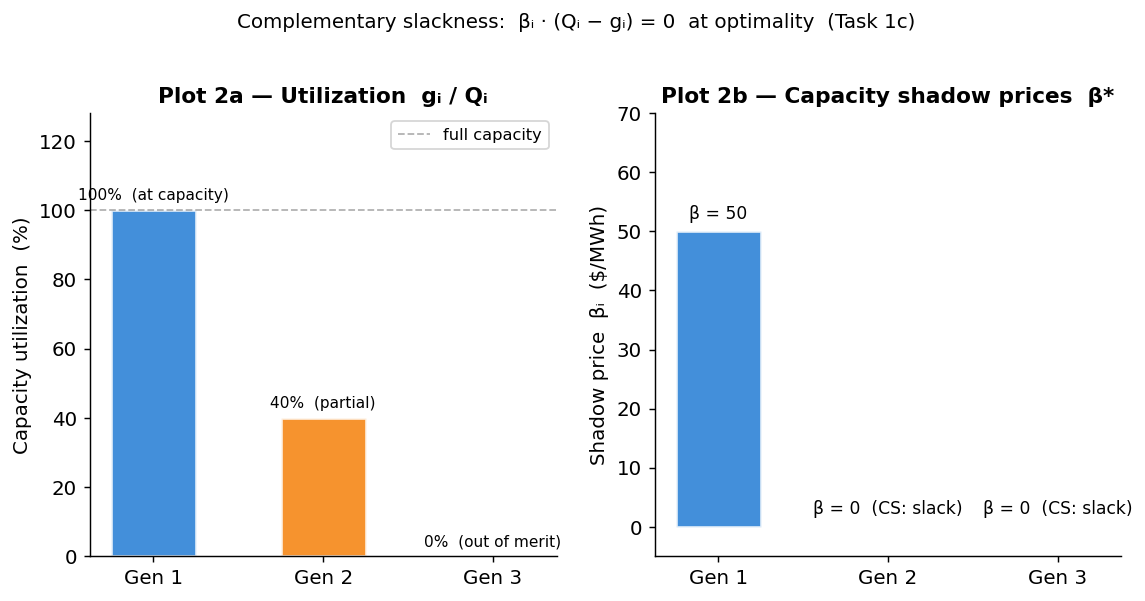

In [3]:
# ── Plot 2: Complementary slackness panel ────────────────────────────────────
# Left: capacity utilization g_i/Q_i. Right: shadow price β_i.
# CS requires β_i · (Q_i − g_i) = 0 at optimality:
#   Gen 1 at 100% → β₁ > 0 is allowed.
#   Gen 2 partially dispatched → β₂ = 0 is forced.
#   Gen 3 at 0% (out of merit) → β₃ = 0 (dual constraint is slack: 150 ≤ 500).

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
COLS  = ['#1976D2', '#F57C00', '#D32F2F']
gens  = ['Gen 1', 'Gen 2', 'Gen 3']
util  = g / Q * 100

ax = axes[0]
bars = ax.bar(gens, util, color=COLS, alpha=0.82, width=0.5, edgecolor='white', linewidth=1.5)
ax.axhline(100, color='gray', ls='--', lw=1, alpha=0.6, label='full capacity')
ax.set_ylim(0, 128)
ax.set_ylabel('Capacity utilization  (%)', fontsize=11)
ax.set_title('Plot 2a — Utilization  gᵢ / Qᵢ')
ax.legend(fontsize=9)
for bar, u, s in zip(bars, util, dispatch['status']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{u:.0f}%  ({s.replace("_", " ")})',
            ha='center', va='bottom', fontsize=8.5)

ax = axes[1]
bars2 = ax.bar(gens, beta, color=COLS, alpha=0.82, width=0.5, edgecolor='white', linewidth=1.5)
ax.set_ylim(-5, 70)
ax.set_ylabel('Shadow price  βᵢ  ($/MWh)', fontsize=11)
ax.set_title('Plot 2b — Capacity shadow prices  β*')
for bar, b in zip(bars2, beta):
    label = f'β = {b:.0f}' if b > 0.01 else 'β = 0  (CS: slack)'
    ax.text(bar.get_x() + bar.get_width() / 2, max(b, 0) + 1.5,
            label, ha='center', va='bottom', fontsize=9.5)

fig.suptitle('Complementary slackness:  βᵢ · (Qᵢ − gᵢ) = 0  at optimality  (Task 1c)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(r1c, 'complementary_slackness.png'), dpi=150, bbox_inches='tight')
plt.show()

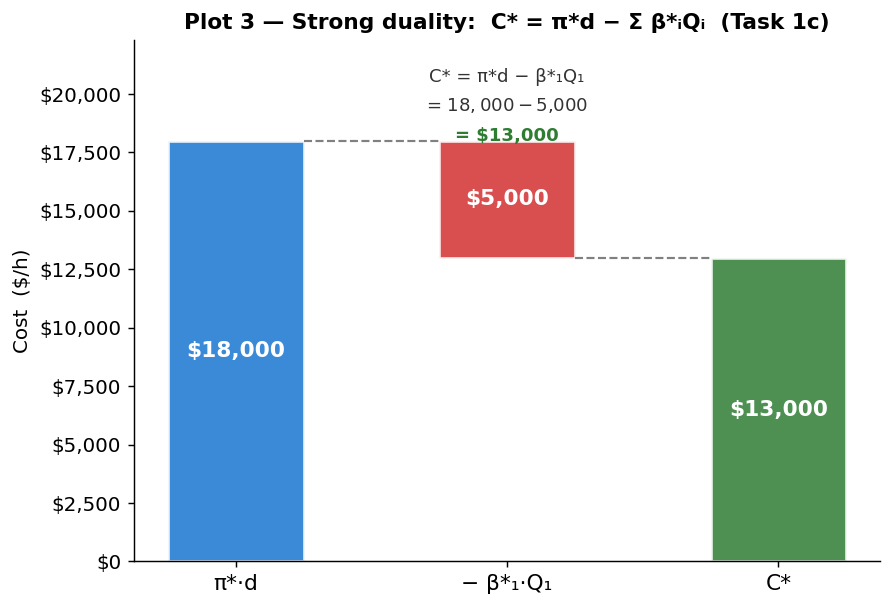

In [4]:
# ── Plot 3: Strong duality waterfall ─────────────────────────────────────────
# Shows C* = π*d − Σ β*ᵢQᵢ as a waterfall:
#   Start  → π*d = $18,000  (what consumers pay at the market price)
#   Deduct → β*₁Q₁ = $5,000 (Gen 1 scarcity rent returned to inframarginal gen)
#   Land   → C* = $13,000   (total dispatch cost = primal objective)
# The equality C* = dual objective value is strong duality.

pi_d   = pi_star * d
beta_Q = float((beta * Q).sum())
C_star = float((c * g).sum())

fig, ax = plt.subplots(figsize=(7, 4.8))

# bar i: (bottom, height, color, x-label)
bars_spec = [
    (0,      pi_d,   '#1976D2', 'π*·d'),
    (C_star, beta_Q, '#D32F2F', '− β*₁·Q₁'),
    (0,      C_star, '#2E7D32', 'C*'),
]

for i, (bot, ht, col, lbl) in enumerate(bars_spec):
    ax.bar(i, ht, bottom=bot, color=col, alpha=0.85, width=0.5,
           edgecolor='white', linewidth=1.5)
    mid = bot + ht / 2
    ax.text(i, mid, f'${ht:,.0f}',
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# connector dashes: top of bar 0 → top of bar 1, bottom of bar 1 → top of bar 2
ax.plot([0.25, 0.75], [pi_d,   pi_d  ], color='gray', lw=1.2, ls='--')
ax.plot([1.25, 1.75], [C_star, C_star], color='gray', lw=1.2, ls='--')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['π*·d', '− β*₁·Q₁', 'C*'], fontsize=12)
ax.set_ylabel('Cost  ($/h)', fontsize=11)
ax.set_title('Plot 3 — Strong duality:  C* = π*d − Σ β*ᵢQᵢ  (Task 1c)')
ax.set_ylim(0, pi_d * 1.24)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

# equation block in top margin
ax.text(1.0, pi_d * 1.14, 'C* = π*d − β*₁Q₁',                 ha='center', fontsize=10, color='#333')
ax.text(1.0, pi_d * 1.07, f'= ${pi_d:,.0f} − ${beta_Q:,.0f}',  ha='center', fontsize=10, color='#333')
ax.text(1.0, pi_d * 1.00, f'= ${C_star:,.0f}',                  ha='center', fontsize=10,
        color='#2E7D32', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(r1c, 'strong_duality_waterfall.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Part 1e — n−1 Security: Monolithic vs. Robust Counterpart

**Reserve costs:** crᵢ = 0.2 × cᵢ = (20, 30, 100) \$/MWh  
**Solution:** g\* = (100, 20, 0) · r\* = (0, 30, 70) · total cost = \$20,900/h  
Both the monolithic enumeration and the robust LP-duality counterpart agree to 1e-6.

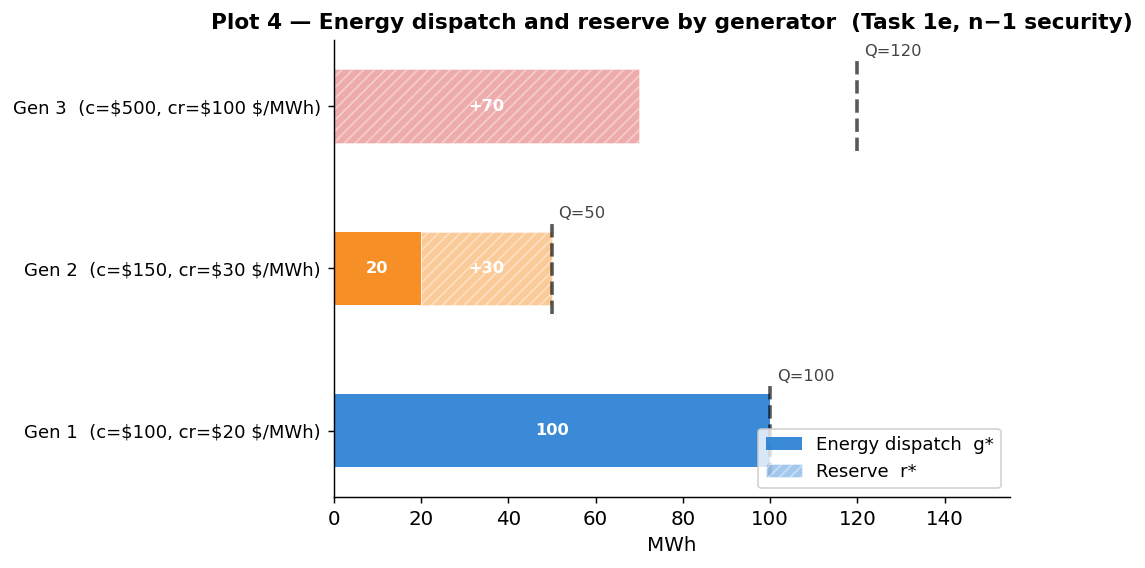

In [5]:
# ── Plot 4: Energy + reserve capacity stack ───────────────────────────────────
# Solid bar = energy dispatch g*; hatched bar (stacked) = reserve r*.
# Dashed vertical line marks the capacity ceiling Q_i.
# Gen 1: fully dispatched for energy, zero reserve room (g₁ = Q₁ = 100).
# Gen 2: 20 MWh energy + 30 MWh reserve = 50 MWh = Q₂ (capacity binding).
# Gen 3: 0 MWh energy + 70 MWh reserve (cheapest way to cover contingency k=1).

g_m  = dr['g_monolithic'].values
r_m  = dr['r_monolithic'].values
Q_m  = dr['Q_capacity'].values
c_m  = dr['c_energy'].values
cr_m = dr['cr_reserve'].values

fig, ax = plt.subplots(figsize=(8, 4.5))
COLS = ['#1976D2', '#F57C00', '#D32F2F']
y    = np.arange(3)

ax.barh(y, g_m, height=0.45, color=COLS, alpha=0.85, label='Energy dispatch  g*')
ax.barh(y, r_m, left=g_m, height=0.45, color=COLS, alpha=0.40,
        hatch='////', edgecolor='white', linewidth=0.5, label='Reserve  r*')

for i in range(3):
    # capacity ceiling marker
    ax.plot([Q_m[i], Q_m[i]], [i - 0.28, i + 0.28], color='black', lw=2, ls='--', alpha=0.65)
    ax.text(Q_m[i] + 1.5, i + 0.29, f'Q={Q_m[i]:.0f}', va='bottom', fontsize=9, color='#444')
    # energy value label
    if g_m[i] > 2:
        ax.text(g_m[i] / 2, i, f'{g_m[i]:.0f}',
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    # reserve value label
    if r_m[i] > 2:
        ax.text(g_m[i] + r_m[i] / 2, i, f'+{r_m[i]:.0f}',
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_yticks(y)
ax.set_yticklabels(
    [f'Gen {i+1}  (c=${c_m[i]:.0f}, cr=${cr_m[i]:.0f} $/MWh)' for i in range(3)],
    fontsize=10)
ax.set_xlabel('MWh', fontsize=11)
ax.set_title('Plot 4 — Energy dispatch and reserve by generator  (Task 1e, n−1 security)')
ax.set_xlim(0, 155)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(r1e, 'dispatch_reserve_stack.png'), dpi=150, bbox_inches='tight')
plt.show()

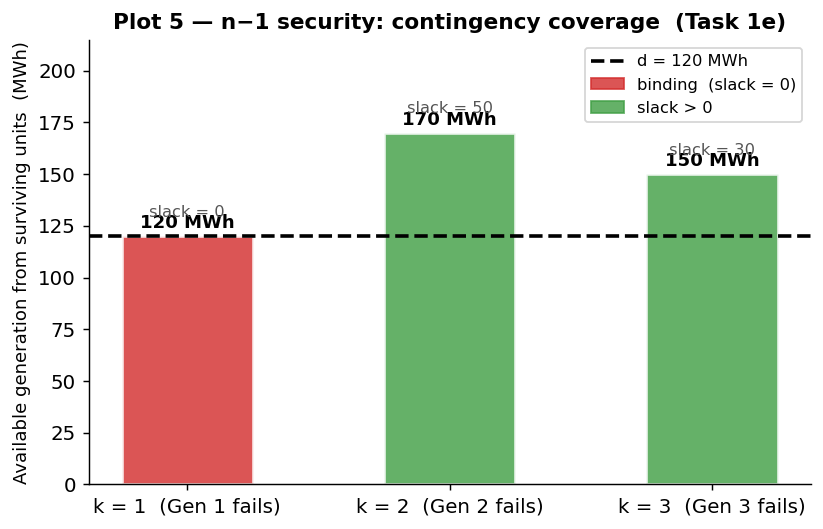

In [6]:
# ── Plot 5: Contingency coverage ─────────────────────────────────────────────
# For each contingency k (generator k fails), shows the total available output
# from the surviving units: Σ_{j≠k} (g*_j + r*_j).
# The demand threshold d = 120 MWh must be met in every contingency.
# k=1 (lose Gen 1) is the binding constraint: exactly 120 MWh available.
# k=2 and k=3 have slack (50 and 30 MWh respectively).

ks    = security['k'].values
cov   = security['coverage'].values
slack = security['slack'].values

fig, ax = plt.subplots(figsize=(6.5, 4.2))

bar_colors = ['#D32F2F' if s < 0.01 else '#43A047' for s in slack]
x_labels   = [f'k = {k}  (Gen {k} fails)' for k in ks]
bars = ax.bar(x_labels, cov, color=bar_colors, alpha=0.82,
              width=0.5, edgecolor='white', linewidth=1.5)

ax.axhline(d, color='black', ls='--', lw=2, label=f'd = {d:.0f} MWh  (demand)')

for bar, cv, sl in zip(bars, cov, slack):
    top = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, top + 2,
            f'{cv:.0f} MWh', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width() / 2, top + 8,
            f'slack = {sl:.0f}', ha='center', va='bottom', fontsize=9, color='#555')

ax.set_ylabel('Available generation from surviving units  (MWh)', fontsize=10)
ax.set_title('Plot 5 — n−1 security: contingency coverage  (Task 1e)')
ax.set_ylim(0, 215)
ax.legend(fontsize=10)

# legend for colors
import matplotlib.patches as mpatches
ax.legend(handles=[
    ax.get_legend_handles_labels()[0][0],
    mpatches.Patch(color='#D32F2F', alpha=0.82, label='binding  (slack = 0)'),
    mpatches.Patch(color='#43A047', alpha=0.82, label='slack > 0'),
], labels=[f'd = {d:.0f} MWh', 'binding  (slack = 0)', 'slack > 0'],
fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(r1e, 'contingency_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()

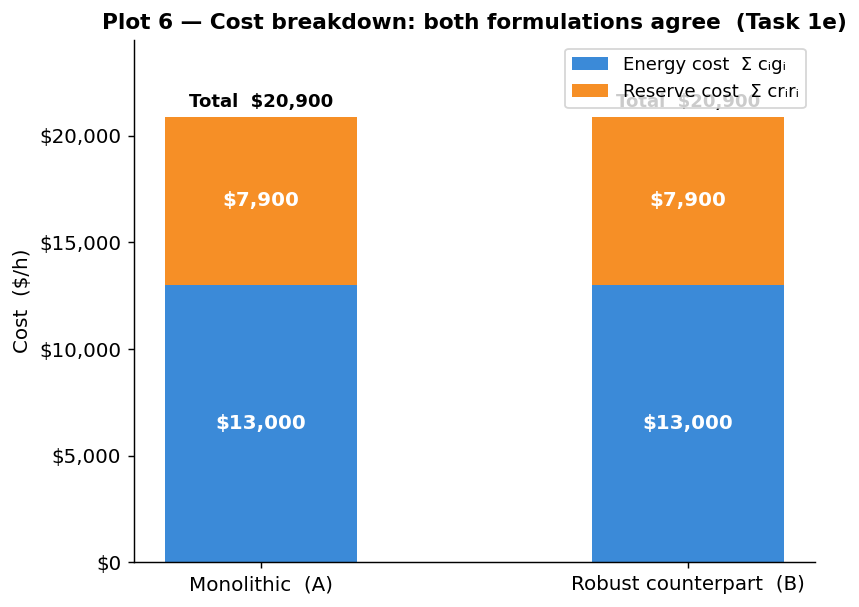

In [7]:
# ── Plot 6: Cost breakdown — monolithic vs. robust counterpart ────────────────
# Both formulations solve to the same optimum. This plot confirms that and
# breaks the total cost into energy (Σ cᵢgᵢ = $13,000) and reserve
# (Σ crᵢrᵢ = $7,900) components.
# The robust counterpart avoids enumerating contingencies explicitly — its
# compact LP has the same solution because LP duality is exact for this inner
# problem (the inner max over the probability simplex is always attained at a
# vertex, so the LP relaxation is tight).

energy_costs  = obj_df['energy_cost'].values
reserve_costs = obj_df['reserve_cost'].values
total_costs   = obj_df['total_cost'].values

fig, ax = plt.subplots(figsize=(6.5, 4.8))
x = np.arange(2)
w = 0.45

ax.bar(x, energy_costs, width=w, color='#1976D2', alpha=0.85, label='Energy cost  Σ cᵢgᵢ')
ax.bar(x, reserve_costs, bottom=energy_costs, width=w,
       color='#F57C00', alpha=0.85, label='Reserve cost  Σ crᵢrᵢ')

for i, (e, r, tot) in enumerate(zip(energy_costs, reserve_costs, total_costs)):
    ax.text(x[i], e / 2,     f'${e:,.0f}', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(x[i], e + r / 2, f'${r:,.0f}', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(x[i], tot + 280, f'Total  ${tot:,.0f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['Monolithic  (A)', 'Robust counterpart  (B)'], fontsize=11)
ax.set_ylabel('Cost  ($/h)', fontsize=11)
ax.set_title('Plot 6 — Cost breakdown: both formulations agree  (Task 1e)')
ax.set_ylim(0, 24500)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(r1e, 'cost_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()